In [70]:
# We install one extra library for pretty correlation heatmaps
!pip install seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# This makes all our plots look nicer inside the notebook
%matplotlib inline
plt.style.use('seaborn-v0_8')

print("✅ All libraries loaded!")

✅ All libraries loaded!


In [71]:
df = pd.read_csv('/content/dataset[1].csv', index_col=0)

print("Shape:", df.shape)         # rows × columns
print("\nColumn names:\n", df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

Shape: (114000, 20)

Column names:
 ['track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']

First 3 rows:


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic


**Exploratory Data Analysis (EDA)**

In [72]:
# Check for missing values
print("=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Basic Statistics ===")
df.describe()

=== Missing Values ===
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

=== Data Types ===
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64


,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [73]:
print("Rows before cleaning:", len(df))

# Remove duplicate tracks (same track_id)
df = df.drop_duplicates(subset='track_id')

# Drop rows with any missing values
df = df.dropna()

print("Rows after cleaning:", len(df))

Rows before cleaning: 114000
Rows after cleaning: 89740


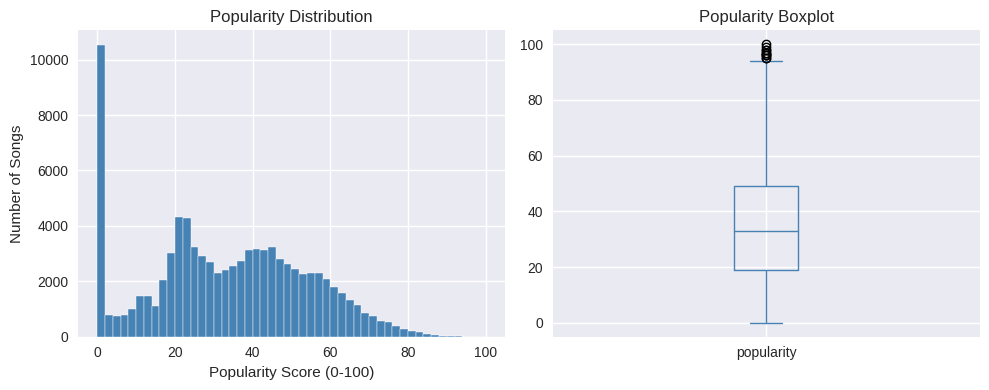

Average popularity: 33.2
Median popularity: 33.0


In [74]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
df['popularity'].hist(bins=50, color='steelblue', edgecolor='white')
plt.title('Popularity Distribution')
plt.xlabel('Popularity Score (0-100)')
plt.ylabel('Number of Songs')

plt.subplot(1, 2, 2)
df['popularity'].plot(kind='box', color='steelblue')
plt.title('Popularity Boxplot')

plt.tight_layout()
plt.show()

print("Average popularity:", df['popularity'].mean().round(2))
print("Median popularity:", df['popularity'].median())

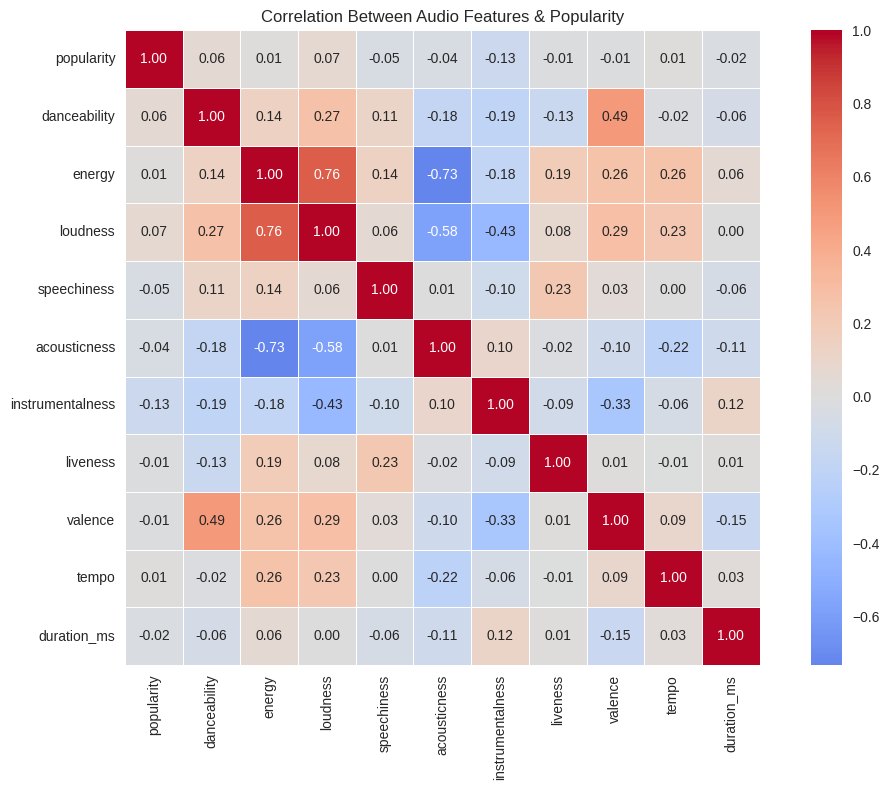

In [75]:
# Select only the numeric audio feature columns
audio_features = ['popularity', 'danceability', 'energy', 'loudness',
                  'speechiness', 'acousticness', 'instrumentalness',
                  'liveness', 'valence', 'tempo', 'duration_ms']

corr_matrix = df[audio_features].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Between Audio Features & Popularity')
plt.tight_layout()
plt.show()

Top features correlated with popularity: ['instrumentalness', 'loudness', 'danceability', 'speechiness']


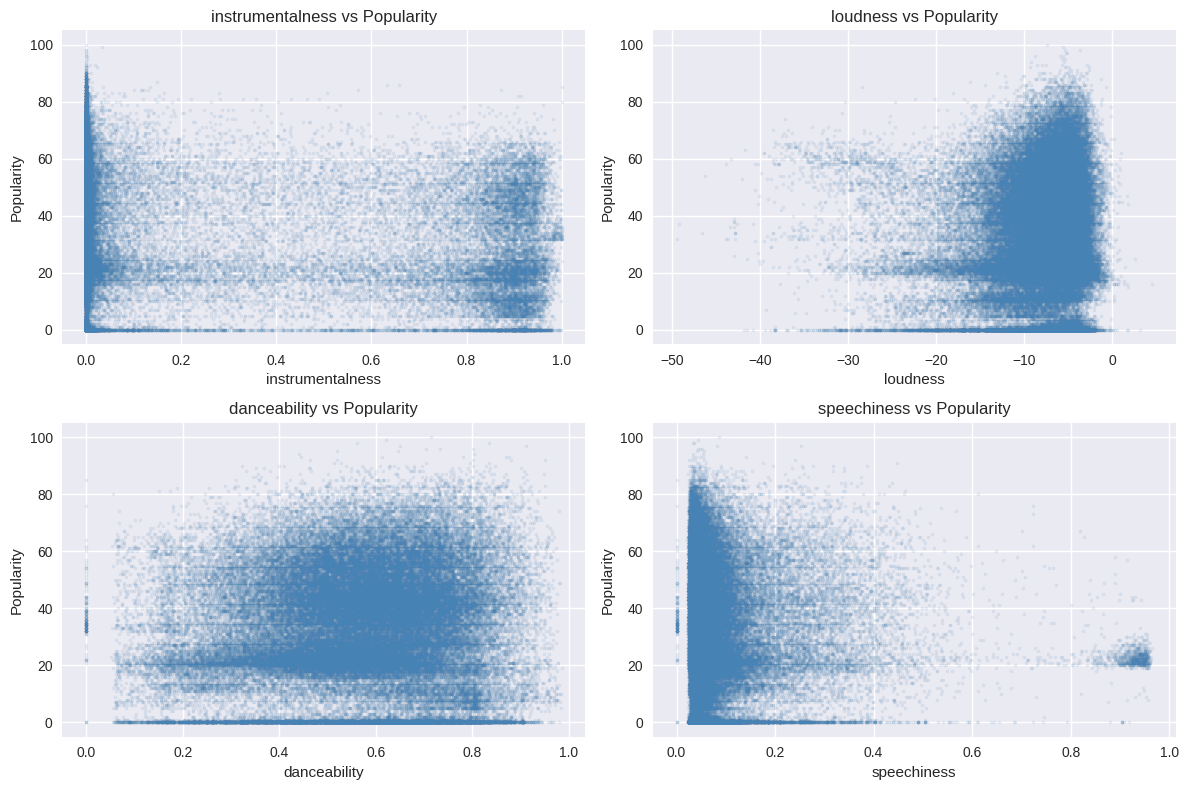

In [76]:
# Find which features correlate most with popularity
top_features = corr_matrix['popularity'].drop('popularity').abs().sort_values(ascending=False).head(4).index.tolist()
print("Top features correlated with popularity:", top_features)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    axes[i].scatter(df[feature], df['popularity'], alpha=0.1, s=5, color='steelblue')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Popularity')
    axes[i].set_title(f'{feature} vs Popularity')

plt.tight_layout()
plt.show()

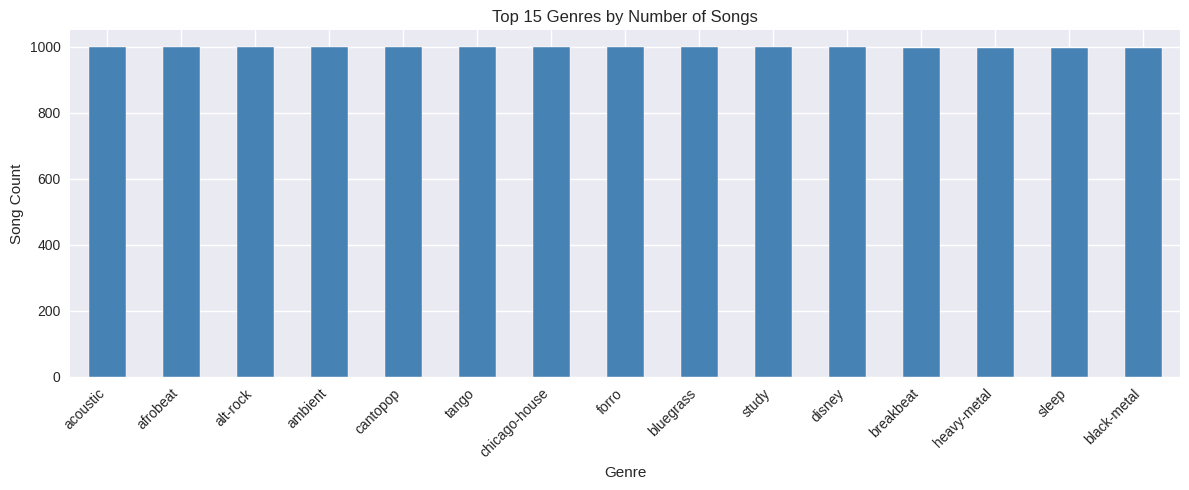

In [77]:
#Top Genres by Song Count
top_genres = df['track_genre'].value_counts().head(15)

plt.figure(figsize=(12, 5))
top_genres.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 15 Genres by Number of Songs')
plt.xlabel('Genre')
plt.ylabel('Song Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [78]:
# Step 1: Check what genres you actually have before filtering
selected_genres = ['pop', 'rock', 'hip-hop', 'classical', 'jazz',
                   'edm', 'country', 'r-n-b', 'blues', 'soul',
                   'metal', 'folk']

genre_df = df[df['track_genre'].isin(selected_genres)]

# ✅ Always verify your filter worked before plotting!
print("Rows after filtering:", len(genre_df))
print("\nGenre counts:")
print(genre_df['track_genre'].value_counts())

Rows after filtering: 7576

Genre counts:
track_genre
country      946
blues        938
classical    867
hip-hop      842
folk         841
edm          694
jazz         524
r-n-b        489
soul         445
pop          416
rock         342
metal        232
Name: count, dtype: int64


In [79]:
compare_features = ['danceability', 'energy', 'acousticness',
                    'valence', 'instrumentalness', 'tempo']

# Group by genre → get mean of each feature
genre_means = genre_df.groupby('track_genre')[compare_features].mean()

# Normalize each COLUMN (feature) to 0–1 so features are comparable
# axis=0 means normalize down each column independently
genre_means_norm = (genre_means - genre_means.min(axis=0)) / \
                   (genre_means.max(axis=0) - genre_means.min(axis=0))

print("Shape of genre_means_norm:", genre_means_norm.shape)
print("\nAny NaN values?", genre_means_norm.isnull().any().any())
genre_means_norm.round(2)

Shape of genre_means_norm: (12, 6)

Any NaN values? False


,danceability,energy,acousticness,valence,instrumentalness,tempo
track_genre,,,,,,
blues,0.53,0.59,0.42,0.83,0.05,0.42
classical,0.00,0.00,1.00,0.00,1.00,0.00
country,0.49,0.61,0.33,0.46,0.00,0.76
edm,0.78,0.86,0.10,0.27,0.07,0.63
folk,0.51,0.56,0.49,0.37,0.06,0.47
hip-hop,1.00,0.77,0.18,0.62,0.02,0.48
jazz,0.30,0.17,0.83,0.37,0.18,0.36
metal,0.28,1.00,0.00,0.13,0.07,1.00
pop,0.57,0.59,0.42,0.33,0.00,0.62


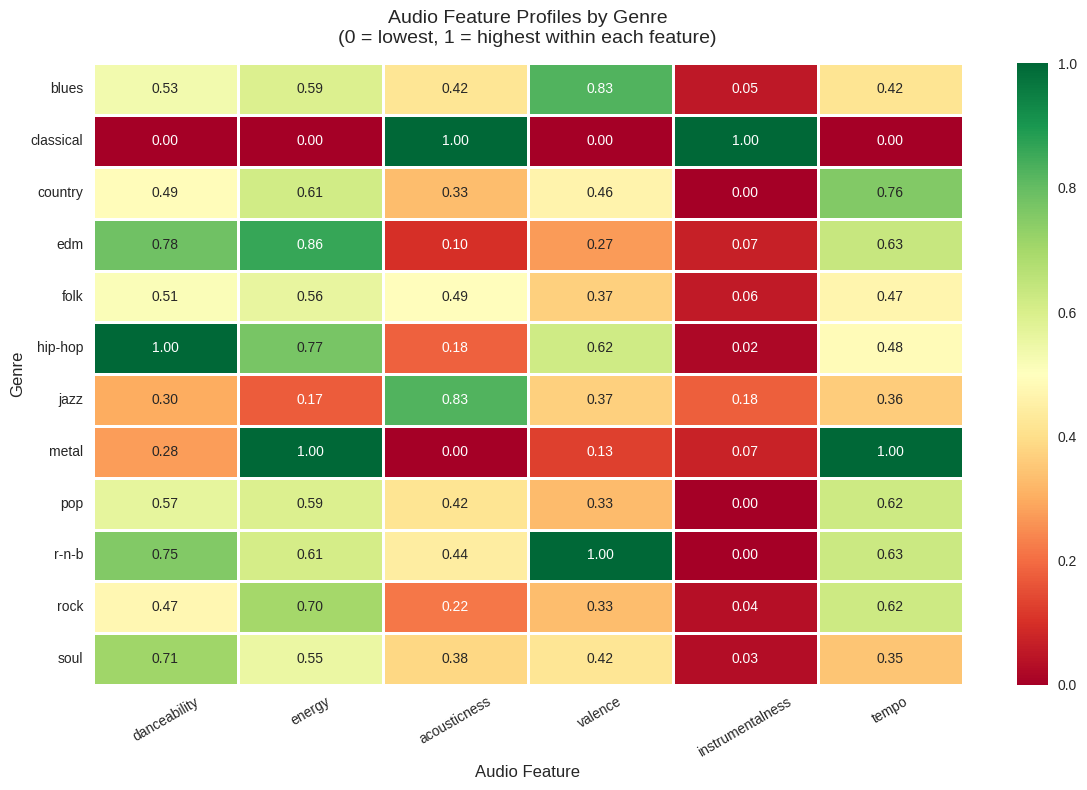

In [80]:
fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(
    genre_means_norm,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',          # Red = low, Yellow = mid, Green = high
    linewidths=0.8,
    linecolor='white',
    ax=ax,
    annot_kws={"size": 10},
    vmin=0, vmax=1           # Force scale from 0 to 1
)

ax.set_title('Audio Feature Profiles by Genre\n(0 = lowest, 1 = highest within each feature)',
             fontsize=14, pad=15)
ax.set_xlabel('Audio Feature', fontsize=12)
ax.set_ylabel('Genre', fontsize=12)
ax.tick_params(axis='x', rotation=30, labelsize=10)
ax.tick_params(axis='y', rotation=0, labelsize=10)

plt.tight_layout()
plt.show()

In [81]:
from sklearn.preprocessing import StandardScaler

# Choose features for clustering
cluster_features = ['danceability', 'energy', 'loudness', 'acousticness',
                    'instrumentalness', 'valence', 'tempo']

# Take a sample (clustering 114k songs is slow)
sample_df = df.sample(n=5000, random_state=42).reset_index(drop=True)

X = sample_df[cluster_features]

# StandardScaler makes all features have mean=0 and std=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data ready for clustering:", X_scaled.shape)

Data ready for clustering: (5000, 7)


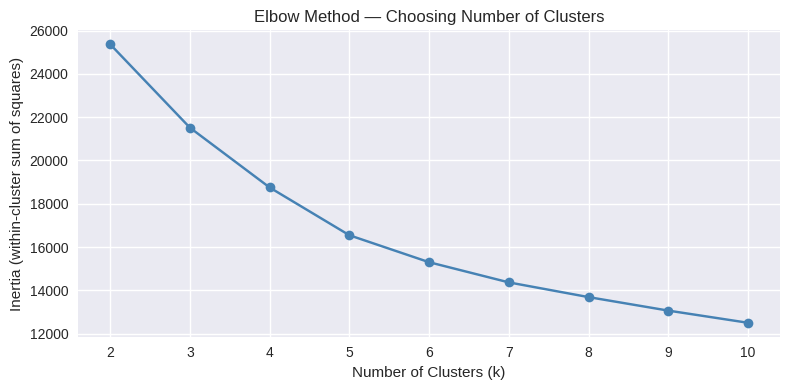

In [82]:
from sklearn.cluster import KMeans

inertia = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', color='steelblue')
plt.title('Elbow Method — Choosing Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (within-cluster sum of squares)')
plt.xticks(k_range)
plt.grid(True)
plt.tight_layout()
plt.show()

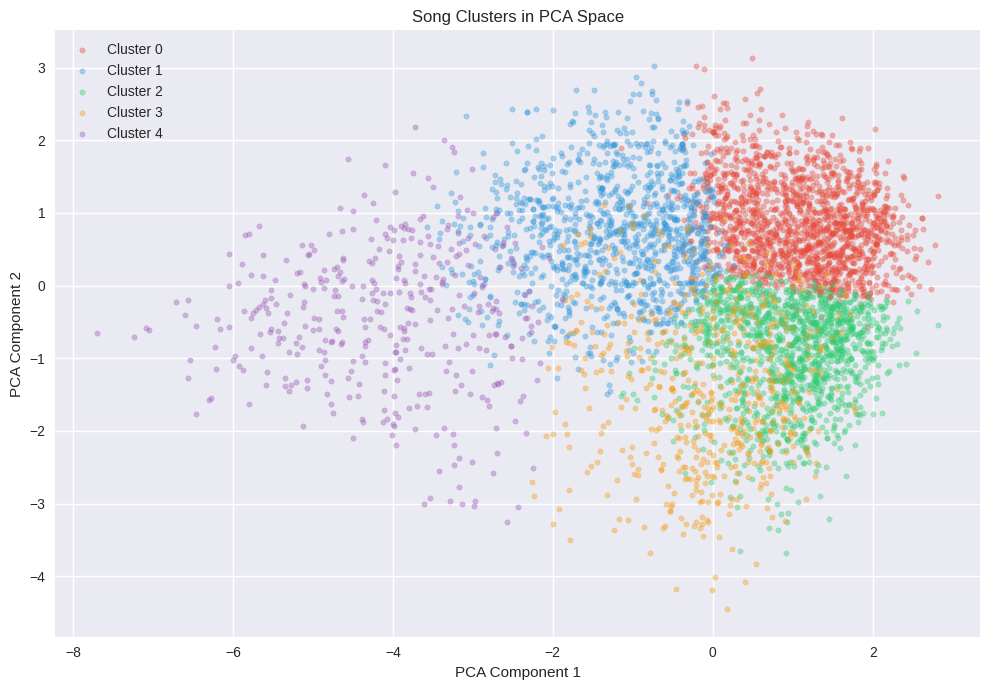

In [83]:
from sklearn.decomposition import PCA

# Apply KMeans with your chosen k (change this after looking at elbow plot)
k = 5
km = KMeans(n_clusters=k, random_state=42, n_init=10)
sample_df['cluster'] = km.fit_predict(X_scaled)

# Use PCA to reduce 7 features → 2D so we can plot it
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
sample_df['pca_x'] = coords[:, 0]
sample_df['pca_y'] = coords[:, 1]

# Plot
plt.figure(figsize=(10, 7))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
for cluster_id in range(k):
    mask = sample_df['cluster'] == cluster_id
    plt.scatter(sample_df.loc[mask, 'pca_x'],
                sample_df.loc[mask, 'pca_y'],
                label=f'Cluster {cluster_id}',
                alpha=0.4, s=15,
                color=colors[cluster_id])

plt.title('Song Clusters in PCA Space')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.tight_layout()
plt.show()

         danceability  energy  loudness  acousticness  instrumentalness  \
cluster                                                                   
0               0.700   0.717    -6.597         0.237             0.020   
1               0.522   0.388   -10.705         0.693             0.037   
2               0.477   0.814    -5.540         0.081             0.031   
3               0.567   0.763    -8.366         0.102             0.799   
4               0.345   0.192   -20.633         0.856             0.765   

         valence    tempo  
cluster                    
0          0.708  119.243  
1          0.411  113.241  
2          0.370  135.479  
3          0.343  128.733  
4          0.175  102.605  


<Figure size 1200x500 with 0 Axes>

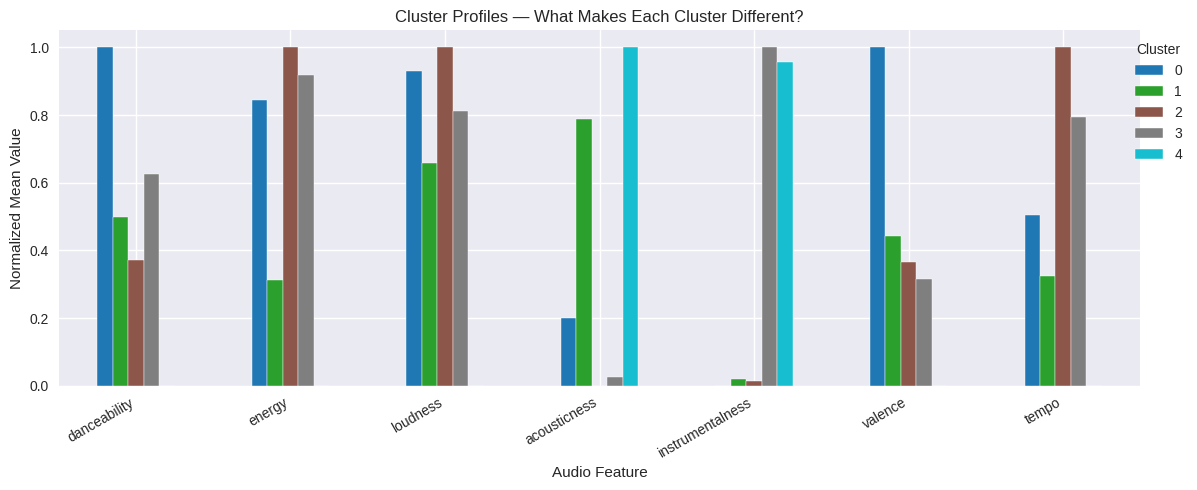

In [84]:
cluster_profiles = sample_df.groupby('cluster')[cluster_features].mean()
print(cluster_profiles.round(3))

# Visualize cluster profiles
cluster_profiles_norm = (cluster_profiles - cluster_profiles.min()) / (cluster_profiles.max() - cluster_profiles.min())

plt.figure(figsize=(12, 5))
cluster_profiles_norm.T.plot(kind='bar', figsize=(12, 5), colormap='tab10', edgecolor='white')
plt.title('Cluster Profiles — What Makes Each Cluster Different?')
plt.xlabel('Audio Feature')
plt.ylabel('Normalized Mean Value')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

**Predicting Popularity (Supervised ML)**

In [85]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# These are our INPUT features (what the model learns from)
feature_cols = ['danceability', 'energy', 'loudness', 'speechiness',
                'acousticness', 'instrumentalness', 'liveness',
                'valence', 'tempo', 'duration_ms']

# This is what we want to PREDICT (the output)
target_col = 'popularity'

X = df[feature_cols]   # inputs  → shape: (rows, 10)
y = df[target_col]     # output  → shape: (rows,)

print("Input shape:", X.shape)
print("Output shape:", y.shape)
print("\nTarget variable stats:")
print(y.describe())

Input shape: (89740, 10)
Output shape: (89740,)

Target variable stats:
count    89740.000000
mean        33.198808
std         20.580640
min          0.000000
25%         19.000000
50%         33.000000
75%         49.000000
max        100.000000
Name: popularity, dtype: float64


In [86]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing, 80% for training
    random_state=42     # fixes the random split so results are reproducible
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 71792
Testing samples: 17948


In [87]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
# Scale features (same reason as clustering — loudness vs danceability scale problem)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)   # ⚠️ use transform only, NOT fit_transform

# Create and train the model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

print("✅ Model trained!")
print("\nModel coefficients (one per feature):")
for feature, coef in zip(feature_cols, lr_model.coef_):
    print(f"  {feature:20s}: {coef:+.4f}")

✅ Model trained!

Model coefficients (one per feature):
  danceability        : +1.8376
  energy              : -0.5710
  loudness            : +0.4585
  speechiness         : -1.3968
  acousticness        : -0.6185
  instrumentalness    : -2.9053
  liveness            : +0.0884
  valence             : -2.2504
  tempo               : +0.1697
  duration_ms         : -0.4690


In [88]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Make predictions on the test set
y_pred_lr = lr_model.predict(X_test_scaled)

# Calculate metrics
mae  = mean_absolute_error(y_test, y_pred_lr)
rmse = mean_squared_error(y_test, y_pred_lr) ** 0.5
r2   = r2_score(y_test, y_pred_lr)

print("=== Linear Regression Results ===")
print(f"MAE  (Mean Absolute Error) : {mae:.2f}")
print(f"RMSE (Root Mean Sq. Error) : {rmse:.2f}")
print(f"R²   (R-squared)           : {r2:.4f}")

=== Linear Regression Results ===
MAE  (Mean Absolute Error) : 16.60
RMSE (Root Mean Sq. Error) : 20.16
R²   (R-squared)           : 0.0286


In [89]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Random Forest builds hundreds of decision trees and averages them
rf_model = RandomForestRegressor(
    n_estimators=100,   # 100 decision trees
    max_depth=10,       # each tree can be at most 10 levels deep
    random_state=42,
    n_jobs=-1           # use all CPU cores to speed up training
)

rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf) ** 0.5
r2_rf   = r2_score(y_test, y_pred_rf)

print("=== Random Forest Results ===")
print(f"MAE  : {mae_rf:.2f}")
print(f"RMSE : {rmse_rf:.2f}")
print(f"R²   : {r2_rf:.4f}")

print("\n=== Improvement over Linear Regression ===")
print(f"R² went from {r2:.4f} → {r2_rf:.4f}")

=== Random Forest Results ===
MAE  : 15.34
RMSE : 19.08
R²   : 0.1293

=== Improvement over Linear Regression ===
R² went from 0.0286 → 0.1293


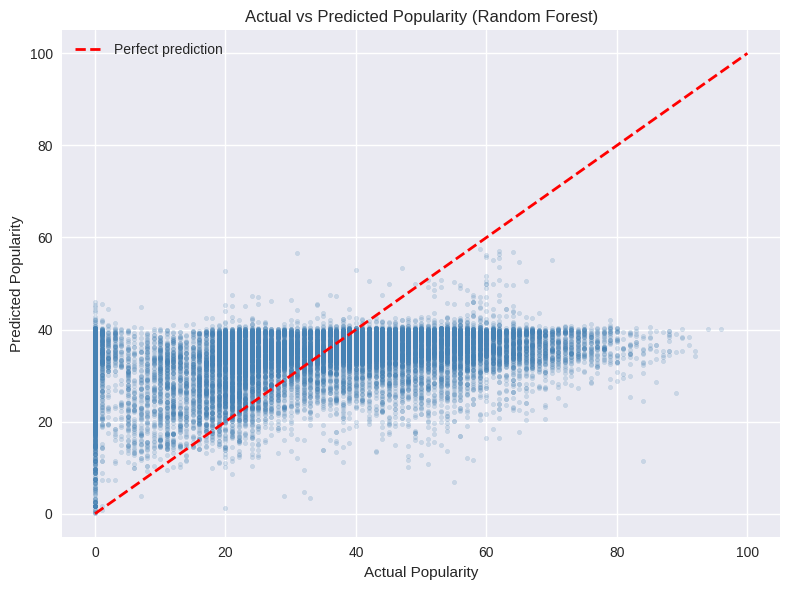

In [90]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.2, s=10, color='steelblue')
plt.plot([0, 100], [0, 100], 'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual Popularity')
plt.ylabel('Predicted Popularity')
plt.title('Actual vs Predicted Popularity (Random Forest)')
plt.legend()
plt.tight_layout()
plt.show()

In [91]:
from sklearn.preprocessing import LabelEncoder

# Convert genre text → numbers so the model can use it
le = LabelEncoder()
df['genre_encoded'] = le.fit_transform(df['track_genre'])

# Add genre to our feature set
feature_cols_v2 = feature_cols + ['genre_encoded']

X2 = df[feature_cols_v2]
y2 = df[target_col]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

scaler2 = StandardScaler()
X_train2_scaled = scaler2.fit_transform(X_train2)
X_test2_scaled  = scaler2.transform(X_test2)

rf_model2 = RandomForestRegressor(n_estimators=100, max_depth=10,
                                   random_state=42, n_jobs=-1)
rf_model2.fit(X_train2_scaled, y_train2)
y_pred2 = rf_model2.predict(X_test2_scaled)

r2_v2 = r2_score(y_test2, y_pred2)
print(f"R² with genre added: {r2_v2:.4f}")
print(f"Improvement: {r2_rf:.4f} → {r2_v2:.4f}")

R² with genre added: 0.2983
Improvement: 0.1293 → 0.2983


In [92]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Define "popular" = top 25% of popularity scores
threshold = df['popularity'].quantile(0.75)
print(f"Popularity threshold for 'popular': {threshold}")

# Create binary label: 1 = popular, 0 = not popular
df['is_popular'] = (df['popularity'] >= threshold).astype(int)
print(f"\nClass distribution:")
print(df['is_popular'].value_counts())

# Use same features + genre
X3 = df[feature_cols_v2]
y3 = df['is_popular']

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X3, y3, test_size=0.2, random_state=42
)

scaler3 = StandardScaler()
X_train3_scaled = scaler3.fit_transform(X_train3)
X_test3_scaled  = scaler3.transform(X_test3)

clf = RandomForestClassifier(n_estimators=100, max_depth=10,
                              random_state=42, n_jobs=-1)
clf.fit(X_train3_scaled, y_train3)
y_pred3 = clf.predict(X_test3_scaled)

print("\n=== Classification Results ===")
print(classification_report(y_test3, y_pred3))

Popularity threshold for 'popular': 49.0

Class distribution:
is_popular
0    67220
1    22520
Name: count, dtype: int64

=== Classification Results ===
              precision    recall  f1-score   support

           0       0.76      1.00      0.86     13534
           1       0.81      0.04      0.08      4414

    accuracy                           0.76     17948
   macro avg       0.78      0.52      0.47     17948
weighted avg       0.77      0.76      0.67     17948



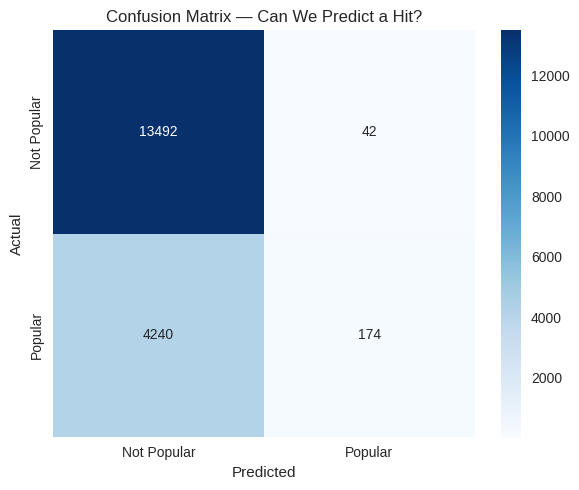

In [93]:
cm = confusion_matrix(y_test3, y_pred3)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Popular', 'Popular'],
            yticklabels=['Not Popular', 'Popular'])
plt.title('Confusion Matrix — Can We Predict a Hit?')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [94]:
!pip install imbalanced-learn --quiet

from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# SMOTE creates synthetic "popular" song examples to balance the dataset
# It looks at existing popular songs and generates similar new ones
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train3_scaled, y_train3)

print("Before SMOTE:")
print(f"  Not Popular: {sum(y_train3 == 0)}, Popular: {sum(y_train3 == 1)}")

print("\nAfter SMOTE:")
print(f"  Not Popular: {sum(y_train_balanced == 0)}, Popular: {sum(y_train_balanced == 1)}")

Before SMOTE:
  Not Popular: 53686, Popular: 18106

After SMOTE:
  Not Popular: 53686, Popular: 53686


In [95]:
clf_balanced = RandomForestClassifier(
    n_estimators=200,       # more trees = more stable
    max_depth=15,           # slightly deeper trees
    class_weight='balanced',# extra penalty for getting popular songs wrong
    random_state=42,
    n_jobs=-1
)

clf_balanced.fit(X_train_balanced, y_train_balanced)
y_pred_balanced = clf_balanced.predict(X_test3_scaled)

print("=== Balanced Model Results ===")
print(classification_report(y_test3, y_pred_balanced,
      target_names=['Not Popular', 'Popular']))

=== Balanced Model Results ===
              precision    recall  f1-score   support

 Not Popular       0.87      0.71      0.78     13534
     Popular       0.43      0.67      0.52      4414

    accuracy                           0.70     17948
   macro avg       0.65      0.69      0.65     17948
weighted avg       0.76      0.70      0.72     17948



/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Liberation Sans.
  fig.canvas.draw()
/tmp/ipykernel_7362/3249949450.py:22: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


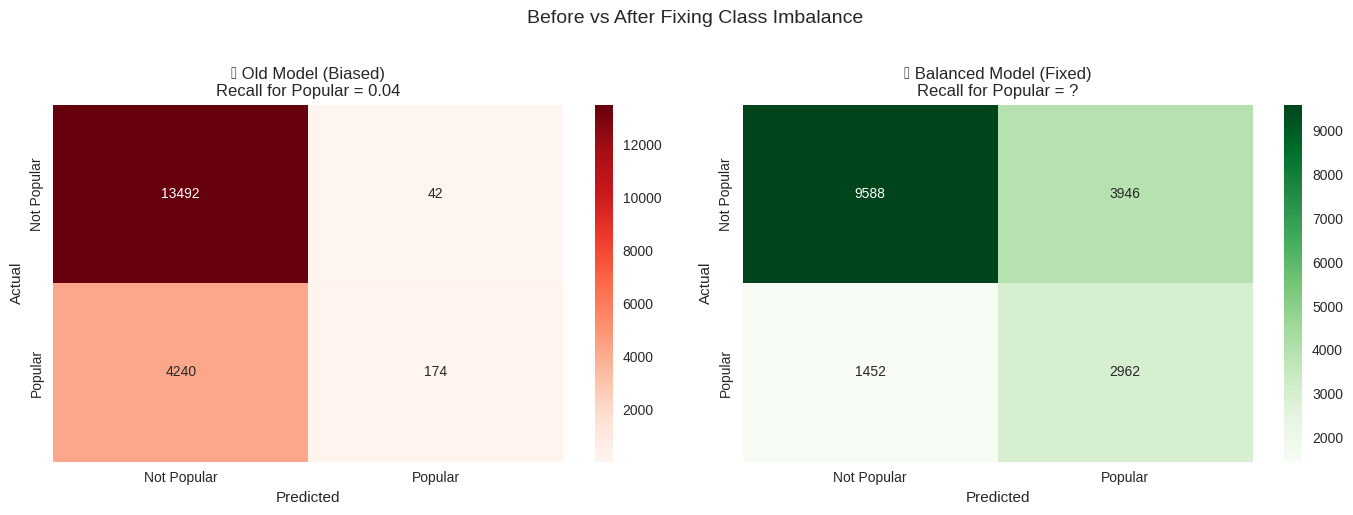

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Old model confusion matrix
cm_old = confusion_matrix(y_test3, y_pred3)
sns.heatmap(cm_old, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=['Not Popular', 'Popular'],
            yticklabels=['Not Popular', 'Popular'])
axes[0].set_title('❌ Old Model (Biased)\nRecall for Popular = 0.04', fontsize=12)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# New balanced model confusion matrix
cm_new = confusion_matrix(y_test3, y_pred_balanced)
sns.heatmap(cm_new, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Not Popular', 'Popular'],
            yticklabels=['Not Popular', 'Popular'])
axes[1].set_title('✅ Balanced Model (Fixed)\nRecall for Popular = ?', fontsize=12)
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.suptitle('Before vs After Fixing Class Imbalance', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

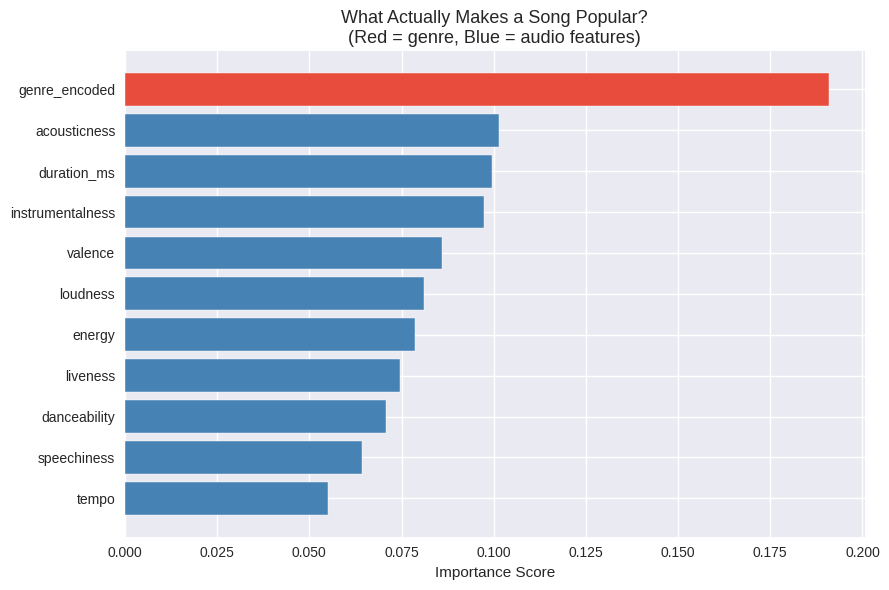


🏆 Top 5 factors that determine popularity:
         feature  importance
   genre_encoded    0.191017
    acousticness    0.101559
     duration_ms    0.099437
instrumentalness    0.097424
         valence    0.085956


In [97]:
importances = clf_balanced.feature_importances_
feat_df = pd.DataFrame({
    'feature': feature_cols_v2,
    'importance': importances
}).sort_values('importance', ascending=True)

plt.figure(figsize=(9, 6))
colors = ['#e74c3c' if f == 'genre_encoded' else 'steelblue'
          for f in feat_df['feature']]
plt.barh(feat_df['feature'], feat_df['importance'],
         color=colors, edgecolor='white')
plt.title('What Actually Makes a Song Popular?\n(Red = genre, Blue = audio features)',
          fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\n🏆 Top 5 factors that determine popularity:")
print(feat_df.sort_values('importance', ascending=False).head(5).to_string(index=False))

In [98]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

# Features we'll use to measure song similarity
rec_features = ['danceability', 'energy', 'loudness', 'speechiness',
                'acousticness', 'instrumentalness', 'liveness',
                'valence', 'tempo', 'duration_ms']

# Work on a clean copy with reset index
rec_df = df[['track_name', 'artists', 'track_genre',
             'popularity'] + rec_features].dropna().reset_index(drop=True)

print("Songs available for recommendation:", len(rec_df))
print("\nSample:")
rec_df.head(3)

Songs available for recommendation: 89740

Sample:


,track_name,artists,track_genre,popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,Comedy,Gen Hoshino,acoustic,73,0.676,0.461,-6.746,0.1430,0.0322,0.000001,0.358,0.715,87.917,230666
1,Ghost - Acoustic,Ben Woodward,acoustic,55,0.420,0.166,-17.235,0.0763,0.9240,0.000006,0.101,0.267,77.489,149610
2,To Begin Again,Ingrid Michaelson;ZAYN,acoustic,57,0.438,0.359,-9.734,0.0557,0.2100,0.000000,0.117,0.120,76.332,210826


In [99]:
# Scale all audio features to same range
rec_scaler = StandardScaler()
rec_scaled = rec_scaler.fit_transform(rec_df[rec_features])

print("Scaled feature matrix shape:", rec_scaled.shape)
print("\n✅ Ready to compute similarities!")

Scaled feature matrix shape: (89740, 10)

✅ Ready to compute similarities!


In [100]:
def recommend_songs(song_name, n_recommendations=5, genre_filter=None):
    """
    Given a song name, returns the most similar songs.

    Parameters:
        song_name       : str  — name of the song to base recommendations on
        n_recommendations: int — how many songs to return (default 5)
        genre_filter    : str  — optional, restrict results to one genre
    """

    # ── Step 1: Find the song in our dataset ──────────────────────────
    matches = rec_df[rec_df['track_name'].str.lower() == song_name.lower()]

    if matches.empty:
        # Try partial match if exact match fails
        matches = rec_df[rec_df['track_name'].str.lower().str.contains(
                         song_name.lower(), na=False)]

    if matches.empty:
        print(f"❌ Song '{song_name}' not found in dataset.")
        print("\nTry one of these similar names:")
        close = rec_df[rec_df['track_name'].str.lower().str.contains(
                       song_name.lower()[:4], na=False)]['track_name'].unique()[:5]
        print(list(close))
        return None

    # If multiple versions exist, pick the most popular one
    input_song = matches.sort_values('popularity', ascending=False).iloc[0]
    input_idx  = input_song.name  # row index

    print(f"🎵 Finding songs similar to:")
    print(f"   '{input_song['track_name']}' by {input_song['artists']}")
    print(f"   Genre: {input_song['track_genre']} | Popularity: {input_song['popularity']}")
    print()

    # ── Step 2: Compute similarity to ALL other songs ─────────────────
    input_vector = rec_scaled[input_idx].reshape(1, -1)
    similarities = cosine_similarity(input_vector, rec_scaled)[0]

    # ── Step 3: Rank by similarity ────────────────────────────────────
    rec_df_copy = rec_df.copy()
    rec_df_copy['similarity'] = similarities

    # Remove the input song itself from results
    rec_df_copy = rec_df_copy.drop(index=input_idx)

    # Optional: filter by genre
    if genre_filter:
        rec_df_copy = rec_df_copy[rec_df_copy['track_genre'] == genre_filter]

    # Sort by similarity first, then popularity as tiebreaker
    results = rec_df_copy.sort_values(
        ['similarity', 'popularity'],
        ascending=[False, False]
    ).head(n_recommendations)

    # ── Step 4: Display results ───────────────────────────────────────
    print(f"🎧 Top {n_recommendations} Recommendations:")
    print("─" * 65)

    for rank, (_, row) in enumerate(results.iterrows(), 1):
        print(f"{rank}. {row['track_name']}")
        print(f"   Artist : {row['artists']}")
        print(f"   Genre  : {row['track_genre']}")
        print(f"   Similarity : {row['similarity']:.3f} | Popularity: {row['popularity']}")
        print()

    return results

print("✅ Recommender function ready!")

✅ Recommender function ready!


In [101]:
# Try with any song from the dataset!
recommend_songs("Shape of You")

🎵 Finding songs similar to:
   'Shape of You' by Ed Sheeran
   Genre: pop | Popularity: 86

🎧 Top 5 Recommendations:
─────────────────────────────────────────────────────────────────
1. Tene
   Artist : Larry Gaaga;Flavour
   Genre  : dancehall
   Similarity : 0.978 | Popularity: 0

2. Yaaro
   Artist : Santesh;Amos Paul
   Genre  : malay
   Similarity : 0.977 | Popularity: 29

3. Separemos Nuestras Vidas
   Artist : Jerry Rivera
   Genre  : salsa
   Similarity : 0.976 | Popularity: 30

4. Brujeria
   Artist : El Gran Combo De Puerto Rico
   Genre  : salsa
   Similarity : 0.975 | Popularity: 65

5. Low
   Artist : Larry Gaaga;Wizkid
   Genre  : dancehall
   Similarity : 0.973 | Popularity: 54



,track_name,artists,track_genre,popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,similarity
20434,Tene,Larry Gaaga;Flavour,dancehall,0,0.830,0.766,-3.386,0.0963,0.671,0.006810,0.1540,0.932,94.995,230400,0.977628
58946,Yaaro,Santesh;Amos Paul,malay,29,0.801,0.673,-4.989,0.0657,0.569,0.000000,0.1010,0.789,90.008,225333,0.977201
75818,Separemos Nuestras Vidas,Jerry Rivera,salsa,30,0.803,0.702,-5.154,0.0427,0.640,0.000010,0.0715,0.894,102.516,230973,0.975829
75706,Brujeria,El Gran Combo De Puerto Rico,salsa,65,0.795,0.623,-5.375,0.0461,0.565,0.000011,0.0620,0.960,93.030,205813,0.974619
20693,Low,Larry Gaaga;Wizkid,dancehall,54,0.762,0.587,-2.862,0.0751,0.620,0.002520,0.0844,0.772,101.964,233012,0.972784


In [102]:
# Get more recommendations
recommend_songs("Blinding Lights", n_recommendations=8)

🎵 Finding songs similar to:
   'Blinding Lights' by The Weeknd
   Genre: pop | Popularity: 91

🎧 Top 8 Recommendations:
─────────────────────────────────────────────────────────────────
1. BODY
   Artist : LICK;LUNA AURA
   Genre  : club
   Similarity : 0.987 | Popularity: 43

2. Broken
   Artist : Netsky;Montell2099
   Genre  : drum-and-bass
   Similarity : 0.986 | Popularity: 54

3. Blinding Lights
   Artist : The Weeknd
   Genre  : pop
   Similarity : 0.984 | Popularity: 3

4. Blinding Lights
   Artist : The Weeknd
   Genre  : pop
   Similarity : 0.984 | Popularity: 3

5. Blinding Lights
   Artist : The Weeknd
   Genre  : pop
   Similarity : 0.984 | Popularity: 0

6. Blinding Lights
   Artist : The Weeknd
   Genre  : pop
   Similarity : 0.984 | Popularity: 0

7. Shooting Star
   Artist : Nam Woo-hyun
   Genre  : singer-songwriter
   Similarity : 0.982 | Popularity: 43

8. Viah
   Artist : Jass Manak
   Genre  : hip-hop
   Similarity : 0.981 | Popularity: 59



,track_name,artists,track_genre,popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,similarity
16186,BODY,LICK;LUNA AURA,club,43,0.488,0.674,-6.344,0.0729,0.01290,0.007850,0.1250,0.370,170.046,208941,0.986905
25596,Broken,Netsky;Montell2099,drum-and-bass,54,0.518,0.806,-6.538,0.0429,0.04830,0.001050,0.0950,0.327,172.954,199768,0.986136
67672,Blinding Lights,The Weeknd,pop,3,0.512,0.796,-4.075,0.0645,0.00147,0.000209,0.0938,0.344,171.014,201573,0.983721
67675,Blinding Lights,The Weeknd,pop,3,0.512,0.796,-4.075,0.0645,0.00147,0.000209,0.0938,0.344,171.014,201573,0.983721
67671,Blinding Lights,The Weeknd,pop,0,0.512,0.796,-4.075,0.0645,0.00147,0.000209,0.0938,0.344,171.014,201573,0.983721
67673,Blinding Lights,The Weeknd,pop,0,0.512,0.796,-4.075,0.0645,0.00147,0.000209,0.0938,0.344,171.014,201573,0.983721
79027,Shooting Star,Nam Woo-hyun,singer-songwriter,43,0.485,0.690,-4.452,0.0520,0.06310,0.000000,0.0863,0.292,172.401,207866,0.981910
45776,Viah,Jass Manak,hip-hop,59,0.533,0.757,-6.730,0.0453,0.00733,0.000000,0.1110,0.358,169.975,162441,0.980901


In [103]:
# Restrict to a specific genre
recommend_songs("Bohemian Rhapsody", n_recommendations=5, genre_filter='rock')

🎵 Finding songs similar to:
   'Bohemian Rhapsody' by Queen
   Genre: rock | Popularity: 75

🎧 Top 5 Recommendations:
─────────────────────────────────────────────────────────────────
1. A Thousand Years (feat. Steve Kazee) - Pt. 2; The Twilight Saga: Breaking Dawn Soundtrack
   Artist : Christina Perri;Steve Kazee
   Genre  : rock
   Similarity : 0.854 | Popularity: 65

2. All I Want
   Artist : Kodaline
   Genre  : rock
   Similarity : 0.837 | Popularity: 82

3. (Everything I Do) I Do It For You
   Artist : Bryan Adams
   Genre  : rock
   Similarity : 0.817 | Popularity: 2

4. (Everything I Do) I Do It For You
   Artist : Bryan Adams
   Genre  : rock
   Similarity : 0.802 | Popularity: 76

5. Let's Make A Night To Remember
   Artist : Bryan Adams
   Genre  : rock
   Similarity : 0.729 | Popularity: 0



,track_name,artists,track_genre,popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,similarity
73110,A Thousand Years (feat. Steve Kazee) - Pt. 2; ...,Christina Perri;Steve Kazee,rock,65,0.272,0.281,-8.131,0.0307,0.6180,0.000000,0.1110,0.152,138.856,305893,0.854236
72922,All I Want,Kodaline,rock,82,0.188,0.411,-9.733,0.0484,0.1740,0.153000,0.0843,0.159,187.376,305746,0.836807
73009,(Everything I Do) I Do It For You,Bryan Adams,rock,2,0.526,0.365,-12.605,0.0280,0.0775,0.000014,0.0618,0.254,131.251,394133,0.816875
73028,(Everything I Do) I Do It For You,Bryan Adams,rock,76,0.533,0.360,-12.633,0.0282,0.0805,0.000010,0.0631,0.299,131.229,393640,0.801931
73014,Let's Make A Night To Remember,Bryan Adams,rock,0,0.470,0.621,-6.763,0.0253,0.2060,0.000725,0.1350,0.396,175.906,378906,0.729391


In [104]:
def search_songs(query):
    """Search for songs containing a keyword"""
    results = rec_df[rec_df['track_name'].str.lower().str.contains(
                     query.lower(), na=False)][['track_name', 'artists',
                                                'track_genre', 'popularity']]
    results = results.sort_values('popularity', ascending=False).head(10)
    print(f"🔍 Songs matching '{query}':")
    print(results.to_string(index=False))

# Use this if recommend_songs says song not found
search_songs("love")
search_songs("night")

🔍 Songs matching 'love':
                                    track_name                                artists track_genre  popularity
                                  Another Love                              Tom Odell       chill          93
                          lovely (with Khalid)                   Billie Eilish;Khalid         pop          89
                                 I Love You So                            The Walters       indie          89
                             Someone You Loved                          Lewis Capaldi         pop          87
                  Only Love Can Hurt Like This                           Paloma Faith     british          87
                                         Lover                           Taylor Swift         pop          85
                        Crazy What Love Can Do David Guetta;Becky Hill;Ella Henderson         edm          85
                                     LOVE DIVE                                    IVE       k-p

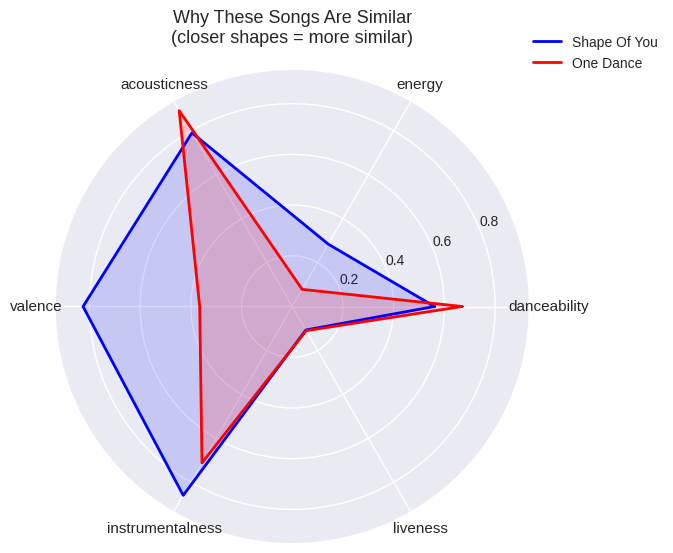

In [105]:
def explain_recommendation(song_name, recommended_song):
    """
    Shows a radar chart comparing the input song vs a recommended song
    so you can SEE why they were matched
    """
    features_to_plot = ['danceability', 'energy', 'acousticness',
                        'valence', 'instrumentalness', 'liveness']

    song1 = rec_df[rec_df['track_name'].str.lower() == song_name.lower()]
    song2 = rec_df[rec_df['track_name'].str.lower() == recommended_song.lower()]

    if song1.empty or song2.empty:
        print("One of the songs wasn't found")
        return

    song1 = song1.iloc[0]
    song2 = song2.iloc[0]

    vals1 = song1[features_to_plot].values.tolist()
    vals2 = song2[features_to_plot].values.tolist()

    # Close the radar chart loop
    vals1 += vals1[:1]
    vals2 += vals2[:1]

    angles = [n / float(len(features_to_plot)) * 2 * 3.14159
              for n in range(len(features_to_plot))]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

    ax.plot(angles, vals1, 'b-', linewidth=2, label=song1['track_name'])
    ax.fill(angles, vals1, 'b', alpha=0.15)

    ax.plot(angles, vals2, 'r-', linewidth=2, label=song2['track_name'])
    ax.fill(angles, vals2, 'r', alpha=0.15)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(features_to_plot, size=11)
    ax.set_title('Why These Songs Are Similar\n(closer shapes = more similar)',
                 size=13, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

    plt.tight_layout()
    plt.show()

# Example — compare input song with a recommendation
# Replace with actual song names from your results
explain_recommendation("Shape of You", "One Dance")

In [106]:
import pickle
import os
from google.colab import drive

# Mount Google Drive so we can save files permanently
drive.mount('/content/drive')

# Create a folder for our project
os.makedirs('/content/drive/MyDrive/MusicIQ', exist_ok=True)

# Save the Random Forest classifier (hit predictor)
with open('/content/drive/MyDrive/MusicIQ/hit_predictor.pkl', 'wb') as f:
    pickle.dump(clf_balanced, f)

# Save the scaler (MUST save this too — same scaler used during training)
with open('/content/drive/MyDrive/MusicIQ/scaler.pkl', 'wb') as f:
    pickle.dump(scaler3, f)

# Save the recommender scaler
with open('/content/drive/MyDrive/MusicIQ/rec_scaler.pkl', 'wb') as f:
    pickle.dump(rec_scaler, f)

# Save the cleaned dataset for recommender
rec_df.to_csv('/content/drive/MyDrive/MusicIQ/rec_data.csv', index=False)

print("✅ All files saved to Google Drive!")
print("\nFiles saved:")
print("  - hit_predictor.pkl  → your trained ML model")
print("  - scaler.pkl         → feature scaler for predictions")
print("  - rec_scaler.pkl     → scaler for recommender")
print("  - rec_data.csv       → song data for recommender")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ All files saved to Google Drive!

Files saved:
  - hit_predictor.pkl  → your trained ML model
  - scaler.pkl         → feature scaler for predictions
  - rec_scaler.pkl     → scaler for recommender
  - rec_data.csv       → song data for recommender


In [107]:
import os

files = os.listdir('/content/drive/MyDrive/MusicIQ/')
print("Files in MusicIQ folder:")
for f in files:
    size = os.path.getsize(f'/content/drive/MyDrive/MusicIQ/{f}')
    print(f"  {f:30s} → {size/1024/1024:.2f} MB")

Files in MusicIQ folder:
  hit_predictor.pkl              → 89.82 MB
  scaler.pkl                     → 0.00 MB
  rec_scaler.pkl                 → 0.00 MB
  rec_data.csv                   → 9.74 MB
